In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df=pd.read_csv("Customer-Churn_processed (1).csv")


In [34]:
df.shape

(7032, 31)

In [35]:
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingTV_No internet service,StreamingTV_Yes,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,DeviceProtection_No internet service,DeviceProtection_Yes
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,0,0,1,1,0,0,0,0,1
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,1,0,0,0


### Separating independent and dependent variables

In [36]:
X=df.drop("Churn",axis=1)
y=df["Churn"]

In [37]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,DeviceProtection_No internet service,DeviceProtection_Yes
0,0,0,1,0,1,0,1,29.85,29.85,1,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,1,...,0,0,0,1,1,0,0,0,0,1
4,0,0,0,0,2,1,1,70.70,151.65,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,1,0,1,1,24,1,1,84.80,1990.50,0,...,0,1,0,1,1,0,0,0,0,1
7028,0,0,1,1,72,1,1,103.20,7362.90,0,...,0,1,0,0,1,0,1,0,0,1
7029,0,0,1,1,11,0,1,29.60,346.45,1,...,0,0,0,0,0,0,0,0,0,0
7030,1,1,1,0,4,1,1,74.40,306.60,0,...,0,0,0,0,0,0,1,0,0,0


In [38]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7027    0
7028    0
7029    0
7030    1
7031    0
Name: Churn, Length: 7032, dtype: int64

### Train Test Split

In [39]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)


### Standardization

In [40]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,f1_score

In [42]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

for name, model in models.items():

   
    model.fit(X_train_scaled, y_train)

  
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]


    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("-" * 40)
    print(name)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")
    print("-" * 40)

----------------------------------------
Logistic Regression
Accuracy : 0.7953
F1 Score : 0.5822
ROC AUC  : 0.8393
----------------------------------------
----------------------------------------
KNN
Accuracy : 0.7559
F1 Score : 0.5236
ROC AUC  : 0.7662
----------------------------------------
----------------------------------------
Decision Tree
Accuracy : 0.7303
F1 Score : 0.5157
ROC AUC  : 0.6692
----------------------------------------
----------------------------------------
Random Forest
Accuracy : 0.7891
F1 Score : 0.5473
ROC AUC  : 0.8159
----------------------------------------
----------------------------------------
Gradient Boosting
Accuracy : 0.8000
F1 Score : 0.5830
ROC AUC  : 0.8410
----------------------------------------
----------------------------------------
AdaBoost
Accuracy : 0.7929
F1 Score : 0.5499
ROC AUC  : 0.8404
----------------------------------------
----------------------------------------
SVC
Accuracy : 0.7924
F1 Score : 0.5531
ROC AUC  : 0.8035
------

## Gradient Boosting Tuning

In [43]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

params = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.8, 0.9, 1.0]
}

gb = GradientBoostingClassifier(random_state=42)

random_search = RandomizedSearchCV(
    gb,
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:",random_search.best_params_)
print("Best ROC AUC:",random_search.best_score_)

Best Parameters: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
Best ROC AUC: 0.8515070467383078


## Logistic Regression Tuning

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr = LogisticRegression(max_iter=1000)

lr_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=params,
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

lr_search.fit(X_train_scaled, y_train)

print("Best Parameters:", lr_search.best_params_)
print("Best ROC AUC:", lr_search.best_score_)

Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 10}
Best ROC AUC: 0.8475513711752027


## Choosing Gradient Boosting 

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

best_gb = GradientBoostingClassifier(
    subsample=1.0,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

best_gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [46]:
y_pred = best_gb.predict(X_test)
y_prob = best_gb.predict_proba(X_test)[:,1]

In [47]:
y_pred = (y_prob >= 0.3)

## Performance Metrices

In [48]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print(classification_report(y_test,y_pred))

Accuracy : 0.7559241706161137
F1 Score : 0.6254545454545455
ROC AUC  : 0.8408552927597472
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1549
           1       0.53      0.77      0.63       561

    accuracy                           0.76      2110
   macro avg       0.71      0.76      0.72      2110
weighted avg       0.80      0.76      0.77      2110



In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1165  384]
 [ 131  430]]


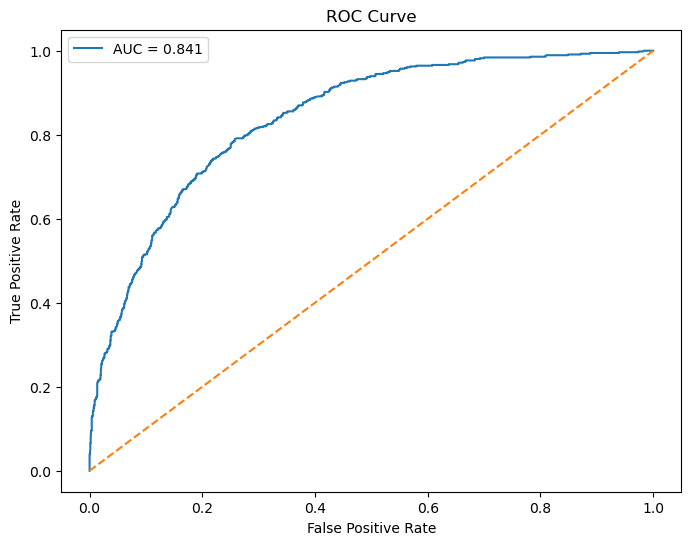

In [50]:
from sklearn.metrics import roc_curve, auc

y_prob = best_gb.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

## Feature Importance

In [51]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                           Feature  Importance
4                           tenure    0.330349
26     InternetService_Fiber optic    0.237405
25               Contract_Two year    0.076244
24               Contract_One year    0.071885
16  PaymentMethod_Electronic check    0.067081
8                     TotalCharges    0.056958
7                   MonthlyCharges    0.051019
14              OnlineSecurity_Yes    0.017792
23                 TechSupport_Yes    0.012357
1                    SeniorCitizen    0.010073


Text(0.5, 0, 'Importance Score')

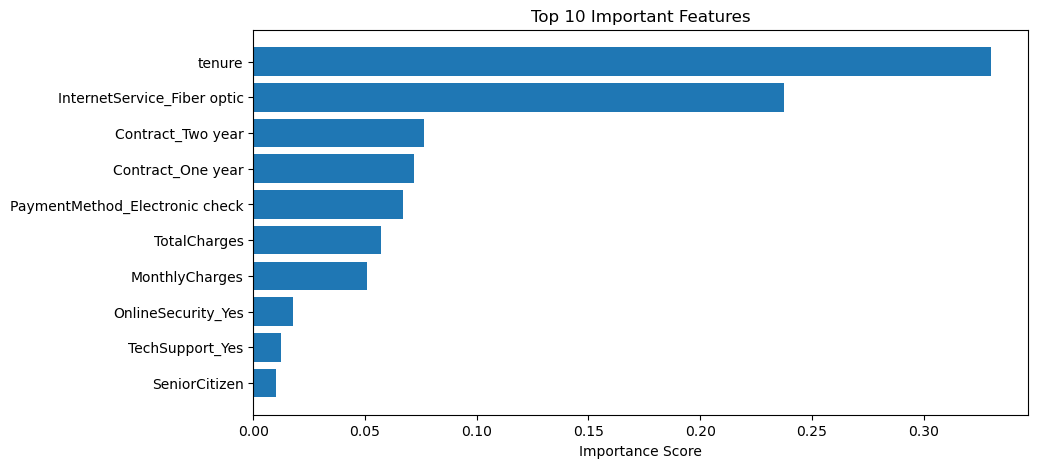

In [52]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,5))
plt.barh(top10['Feature'], top10['Importance'])
plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")

In [53]:
import joblib

joblib.dump(best_gb, "churn_model.pkl")

['churn_model.pkl']

In [54]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes']


In [55]:
import joblib
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']

In [56]:
print(X.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  \
0                 1           29.85         29.85   
1                 0           56.95       1889.50   
2                 1           53.85        108.15   
3                 0           42.30       1840.75   
4                 1           70.70        151.65   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                               1  ...                                0   
1                               0  ...                                0   
2                            